# Artificial Neural Networks (ANNs)


**Author:** *Corneliu Catlabuga*

**Group:** *IS-251M*

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub as kh
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization

%matplotlib inline

/Users/ccatlabuga/Documents/Personal/RNIP/lab1/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

In [2]:
EXAMPLE_DATASET = {
    "dataset": "aakash50897/churn-modellingcsv",
    "file": "Churn_Modelling.csv",
    "redundant_columns": ["RowNumber", "CustomerId", "Surname"],
    "predicted_column": "Exited"
}

CHOSEN_DATASET = {
    "dataset": "amineipad/antenna-performance-and-fault-detection-dataset",
    "file": "antenna_fault.csv",
    # "redundant_columns": ["BT Fault", "BT Status"],
    # "predicted_column": "WiFi Status"
    "redundant_columns": ["WiFi Fault", "WiFi Status", "BT Fault"],
    "predicted_column": "BT Status"
}

WEATHER_DATASET = {
    "dataset": "nikhil7280/weather-type-classification",
    "file": "weather_classification_data.csv",
    "predicted_column": "Weather Type"
}

In [3]:
TARGET_DATASET = WEATHER_DATASET

DATASET = TARGET_DATASET["dataset"]
DOWNLOAD_PATH = f"data/{TARGET_DATASET['dataset']}"
DATASET_FILE = TARGET_DATASET["file"]
REDUNDANT_COLUMNS = TARGET_DATASET.get("redundant_columns", [])
PREDICTED_COLUMN = TARGET_DATASET.get("predicted_column", None)

TEST_SIZE = 0.3
RANDOM_STATE = 101

## Dataset Aquisition

In [4]:
df_path = kh.dataset_download(DATASET, output_dir=DOWNLOAD_PATH)
df = pd.read_csv(f"{df_path}/{DATASET_FILE}")
PREDICTED_CLASS_COUNTS = df[PREDICTED_COLUMN].value_counts()

In [5]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  str    
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  str    
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  str    
 10  Weather Type          13200 non-null  str    
dtypes: float64(5), int64(2), str(4)
memory usage: 1.1 MB


In [7]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


## Data Cleaning

In [8]:
df = df.drop(columns=REDUNDANT_COLUMNS)
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


## Encoding Categorical Variables

In [9]:
le = LabelEncoder()

In [10]:
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])
df.head()

/var/folders/8s/hnrlcfv16rdb1gwgppl6tj1c0000gn/T/ipykernel_57785/2534551035.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,1
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,0
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,3
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,3
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,1


## Data Splitting

In [11]:
X = df.drop(columns=[PREDICTED_COLUMN])
y = df[PREDICTED_COLUMN]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

In [13]:
scaler = StandardScaler()

In [14]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Initial Model

### Model Creation and Compilation

In [15]:
model = Sequential()

model.add(Dense(units=10, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(units=10, activation="relu"))

if len(PREDICTED_CLASS_COUNTS) > 2:
    model.add(Dense(units=len(PREDICTED_CLASS_COUNTS), activation="softmax"))
else:
    model.add(Dense(units=1, activation="sigmoid"))

/Users/ccatlabuga/Documents/Personal/RNIP/lab1/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            44 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264 (1.03 KB)

 Trainable params: 264 (1.03 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
if len(PREDICTED_CLASS_COUNTS) > 2:
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
else:
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

### Model Training

In [18]:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7212 - loss: 0.8132 - val_accuracy: 0.8551 - val_loss: 0.5306
Epoch 2/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - accuracy: 0.8594 - loss: 0.4755 - val_accuracy: 0.8732 - val_loss: 0.4279
Epoch 3/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - accuracy: 0.8737 - loss: 0.4162 - val_accuracy: 0.8806 - val_loss: 0.3950
Epoch 4/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - accuracy: 0.8846 - loss: 0.3870 - val_accuracy: 0.8871 - val_loss: 0.3734
Epoch 5/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - accuracy: 0.8887 - loss: 0.3671 - val_accuracy: 0.8884 - val_loss: 0.3601
Epoch 6/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - accuracy: 0.8908 - loss: 0.3526 - val_accuracy: 0.8876 - val_loss: 0.3507
Epoch 7/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step - accuracy: 0.8946 - loss: 0.3407 - val_accuracy: 0.8922 - val_loss: 0.3395
Epoch 8/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step - accuracy: 0.8952 - loss: 0.3296 - va

### Results Evaluation

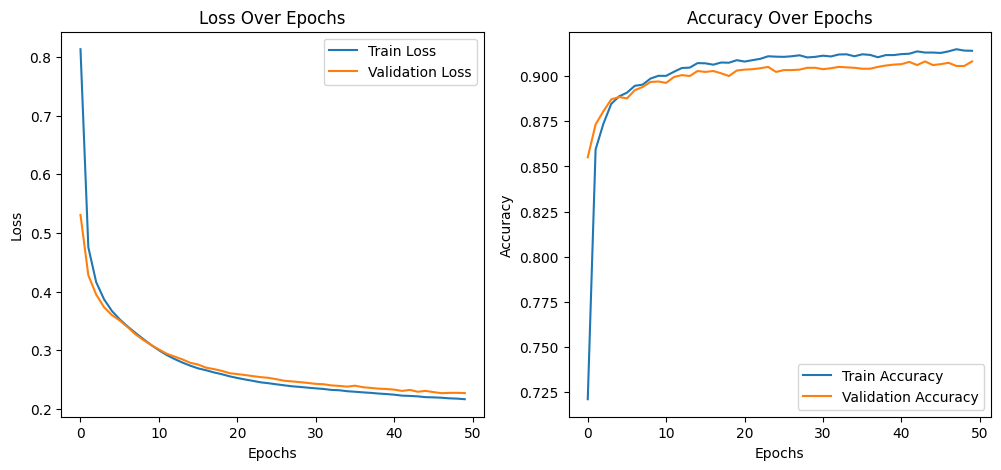

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [20]:
predictions = np.argmax(model.predict(X_test), axis=1) if len(PREDICTED_CLASS_COUNTS) > 2 else (model.predict(X_test) > 0.5).astype("int32")

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step


In [21]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       954
           1       0.88      0.92      0.90       986
           2       0.95      0.94      0.94      1020
           3       0.96      0.88      0.92      1000

    accuracy                           0.91      3960
   macro avg       0.91      0.91      0.91      3960
weighted avg       0.91      0.91      0.91      3960



<Axes: >

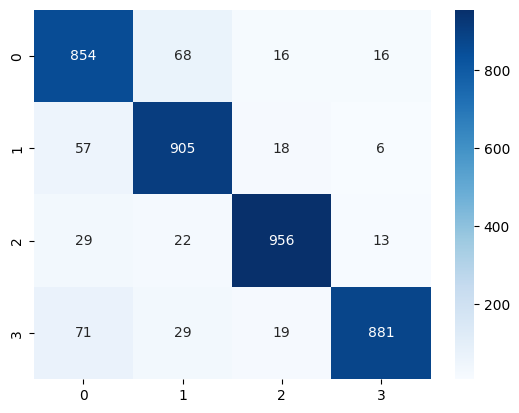

In [22]:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt="d", cmap="Blues")

In [23]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       954
           1       0.88      0.92      0.90       986
           2       0.95      0.94      0.94      1020
           3       0.96      0.88      0.92      1000

    accuracy                           0.91      3960
   macro avg       0.91      0.91      0.91      3960
weighted avg       0.91      0.91      0.91      3960



In [24]:
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

Class Weights: {0: np.float64(0.9846547314578005), 1: np.float64(0.9982713915298185), 2: np.float64(1.013157894736842), 3: np.float64(1.0043478260869565)}


## Optimized Model

### Model Creation and Compilation

In [25]:
optimized_model = Sequential()

optimized_model.add(BatchNormalization(input_shape=(X_train.shape[1],)))

optimized_model.add(Dense(units=128, activation="relu"))
optimized_model.add(Dropout(0.2))
optimized_model.add(BatchNormalization())

optimized_model.add(Dense(units=64, activation="relu"))
optimized_model.add(Dropout(0.2))
optimized_model.add(BatchNormalization())

optimized_model.add(Dense(units=32, activation="relu"))

if len(PREDICTED_CLASS_COUNTS) > 2:
    optimized_model.add(Dense(units=len(PREDICTED_CLASS_COUNTS), activation="softmax"))
else:
    optimized_model.add(Dense(units=1, activation="sigmoid"))

/Users/ccatlabuga/Documents/Personal/RNIP/lab1/venv/lib/python3.13/site-packages/keras/src/layers/normalization/batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
optimized_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,684 (49.55 KB)

 Trainable params: 12,280 (47.97 KB)

 Non-trainable params: 404 (1.58 KB)

In [30]:
if len(PREDICTED_CLASS_COUNTS) > 2:
    optimized_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
else:
    optimized_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

### Model Training

In [31]:
optimized_history = optimized_model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), class_weight=class_weights_dict)

Epoch 1/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8057 - loss: 0.5410 - val_accuracy: 0.8995 - val_loss: 0.2843
Epoch 2/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - accuracy: 0.8692 - loss: 0.3557 - val_accuracy: 0.9010 - val_loss: 0.2299
Epoch 3/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - accuracy: 0.8767 - loss: 0.3158 - val_accuracy: 0.9038 - val_loss: 0.2172
Epoch 4/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.8764 - loss: 0.3048 - val_accuracy: 0.9056 - val_loss: 0.2147
Epoch 5/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.8833 - loss: 0.2877 - val_accuracy: 0.9048 - val_loss: 0.2135
Epoch 6/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - accuracy: 0.8857 - loss: 0.2896 - val_accuracy: 0.9066 - val_loss: 0.2044
Epoch 7/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.8854 - loss: 0.2901 - val_accuracy: 0.9028 - val_loss: 0.2116
Epoch 8/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - accuracy: 0.8850 - loss: 0.2821 - va

### Results Evaluation

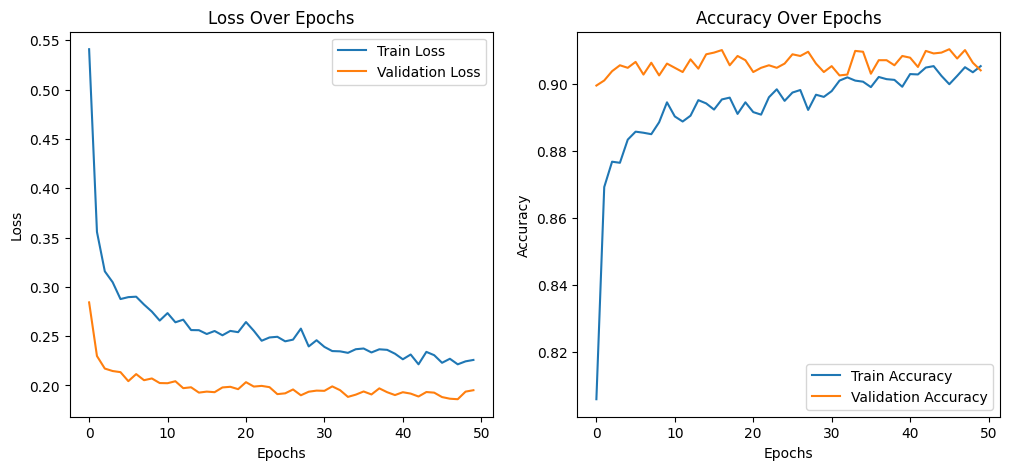

In [32]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(optimized_history.history["loss"], label="Train Loss")
plt.plot(optimized_history.history["val_loss"], label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(optimized_history.history["accuracy"], label="Train Accuracy")
plt.plot(optimized_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [35]:
optimized_predictions = np.argmax(optimized_model.predict(X_test), axis=1) if len(PREDICTED_CLASS_COUNTS) > 2 else (optimized_model.predict(X_test) > 0.5).astype("int32")

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step


In [36]:
print("Accuracy Score:", accuracy_score(y_test, optimized_predictions))

Accuracy Score: 0.9040404040404041


<Axes: >

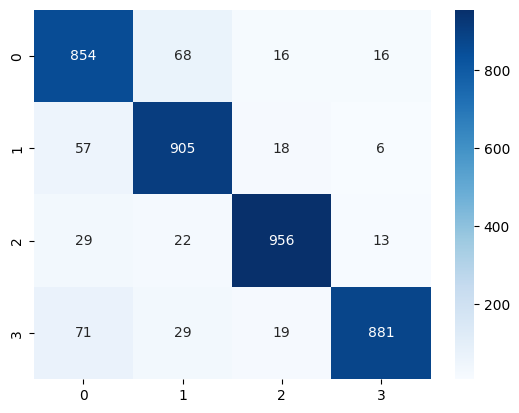

In [37]:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt="d", cmap="Blues")

In [38]:
print(classification_report(y_test, optimized_predictions))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       954
           1       0.91      0.90      0.91       986
           2       0.90      0.95      0.93      1020
           3       0.98      0.86      0.92      1000

    accuracy                           0.90      3960
   macro avg       0.91      0.90      0.90      3960
weighted avg       0.91      0.90      0.90      3960

